/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_22856/4039456510.py:167: F

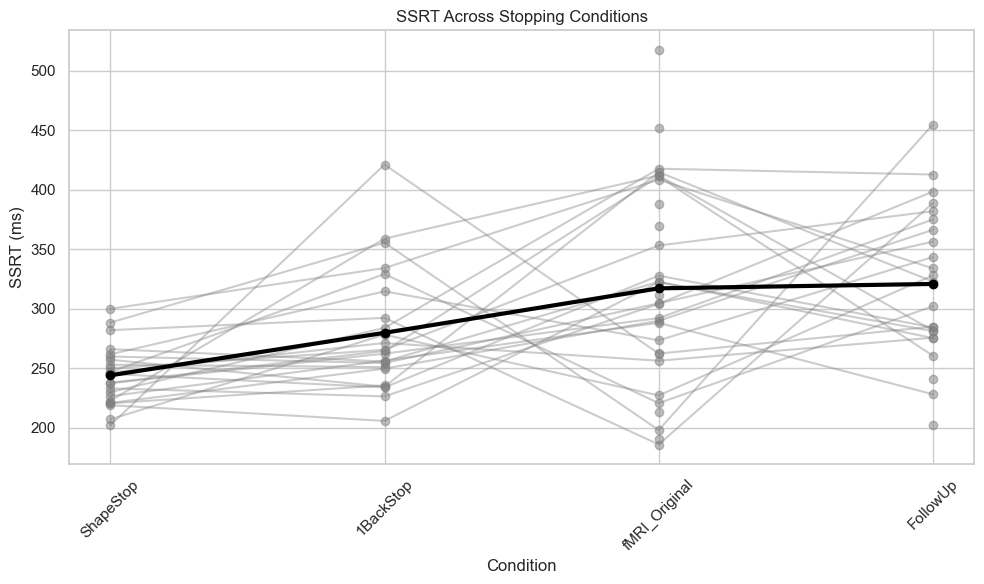

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install openpyxl

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install openpyxl

# ---------------------------
# 1. Define files and their column mappings
# ---------------------------
files_info = {
    "fMRI_Original": {
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/BeastfMRIN30.xlsx",
        "subject_col": "SubjID",
        "rt_col": "RT",
        "stop_acc_col": "StopAcc",
        "ssd_col": "SSD",
        "stop_go_col": "Stop1OrNoStop2",
        "go_code": 2,
        "stop_code": 1,
        "go_acc": "GoAcc",
        "stim_col": "Target1NonTarget2TempNonTarget3",
        "stim_map": {1: "Target", 2: "Non-target", 3: "Lure"}
    },
    "FollowUp": {
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/N23NonFMRIBeast.xlsx",
        "subject_col": "subject_id",
        "rt_col": "RT",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "SS_trial_type",
        "go_code": "go",
        "stop_code": "stop",
        "go_acc": "go_acc",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "1BackStop": {
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/1BackStoppingN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "stop_trial_type",
        "go_code": "go",
        "go_acc": "go_acc",
        "stop_code": "stop",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "NBackNoStop": {  # no stop trials
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/NBackNoStopN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": None,
        "ssd_col": None,
        "stop_go_col": None,
        "go_code": None,
        "stop_code": None,
        "go_acc": None,
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "ShapeStop": {
    "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/StopNoNBackN23.xlsx",
    "subject_col": "subject_ID",
    "rt_col": "rt",
    "stop_acc_col": "stop_acc",
    "ssd_col": "SS_delay",
    "stop_go_col": "SS_trial_type",
    "go_code": "go",     # <-- strings, not 0/1
    "stop_code": "stop",
    "go_acc": "go_acc",
    "shape_col": "go_stim",
    "shape_map": {"black_circle": "Circle", "black_triangle": "Triangle"}
}
}

# ---------------------------
# 2. SSRT computation function
# ---------------------------
def compute_ssrt(df, stop_go_col, stop_acc_col, ssd_col, rt_col, go_code, stop_code):
    df = df.copy()
    
    # skip if no stop trials (e.g., NBackNoStop)
    if stop_go_col is None or stop_acc_col is None or ssd_col is None:
        return np.nan
    
    # Map stop/go to 1 = stop, 2 = go
    df['stop_trial'] = df[stop_go_col].map({stop_code: 1, go_code: 2})
    go_trials = df[df['stop_trial'] == 2]
    stop_trials = df[df['stop_trial'] == 1]
    
    if len(go_trials) == 0 or len(stop_trials) == 0:
        return np.nan
    
    p_respond = 1 - stop_trials[stop_acc_col].mean()
    go_rts = np.sort(go_trials[rt_col].values)
    n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
    n_idx = max(n_idx, 0)
    nth_rt = go_rts[n_idx]
    mean_ssd = stop_trials[ssd_col].mean()
    
    return nth_rt - mean_ssd

# ---------------------------
# 3. Loop through files and compute SSRT
# ---------------------------
ssrt_list = []

for cond_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace
    
    # Robust subject column detection
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    if subject_col is None:
        raise ValueError(f"Subject column not found in {cond_name} dataset")
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    for subj in df['subject'].unique():
        subj_df = df[df['subject'] == subj]
        try:
            ssrt = compute_ssrt(
                subj_df,
                stop_go_col=info.get('stop_go_col'),
                stop_acc_col=info.get('stop_acc_col'),
                ssd_col=info.get('ssd_col'),
                rt_col=info['rt_col'],
                go_code=info.get('go_code'),
                stop_code=info.get('stop_code')
            )
            ssrt_list.append({"subject": subj, "Condition": cond_name, "SSRT": ssrt})
        except Exception as e:
            print(f"Skipping subject {subj} in {cond_name}: {e}")

ssrt_df = pd.DataFrame(ssrt_list)

# Filter extreme SSRTs
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 100) & (ssrt_df['SSRT'] <= 600)]

# ---------------------------
# 4. Plot SSRT across stopping conditions
# ---------------------------
plt.figure(figsize=(10,6))

# Correct order: ShapeStop, 1BackStop, fMRI_Original, FollowUp
condition_order = ["ShapeStop", "1BackStop", "fMRI_Original", "FollowUp"]

# Apply categorical ordering
ssrt_df['Condition'] = pd.Categorical(ssrt_df['Condition'], categories=condition_order, ordered=True)

# Spaghetti plot (each subject)
for sub in ssrt_df['subject'].unique():
    sub_df = ssrt_df[ssrt_df['subject'] == sub].set_index('Condition').reindex(condition_order)
    plt.plot(condition_order, sub_df['SSRT'], color='gray', alpha=0.4)

# Mean line
mean_df = ssrt_df.groupby('Condition')['SSRT'].mean().reindex(condition_order)
plt.plot(condition_order, mean_df, color='black', linewidth=3, marker='o')

# Overlay individual points
for cond in condition_order:
    y_vals = ssrt_df[ssrt_df['Condition'] == cond]['SSRT']
    x_vals = [cond]*len(y_vals)
    plt.scatter(x_vals, y_vals, color='gray', alpha=0.5)

plt.xlabel("Condition")
plt.ylabel("SSRT (ms)")
plt.title("SSRT Across Stopping Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


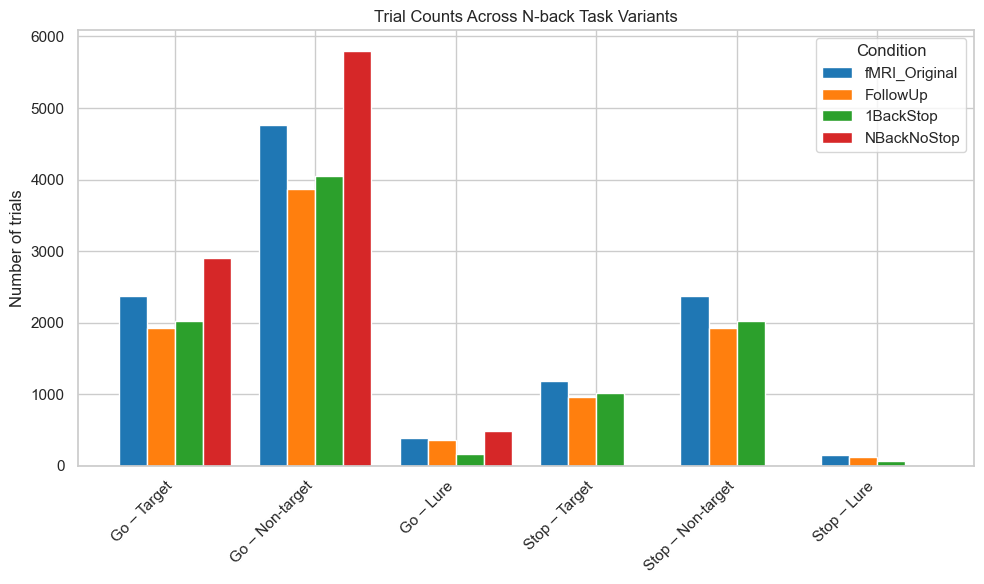

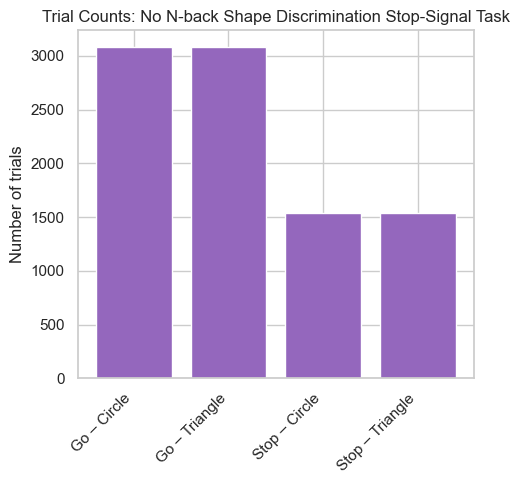

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


            Task   n_go  n_stop  stop_signal_proportion
0  fMRI_Original   7529    3711                0.330160
1       FollowUp   6163    3024                0.329161
2      1BackStop   6236    3102                0.332191
3    NBackNoStop  18749       0                0.000000
4      ShapeStop   6168    3084                0.333333


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


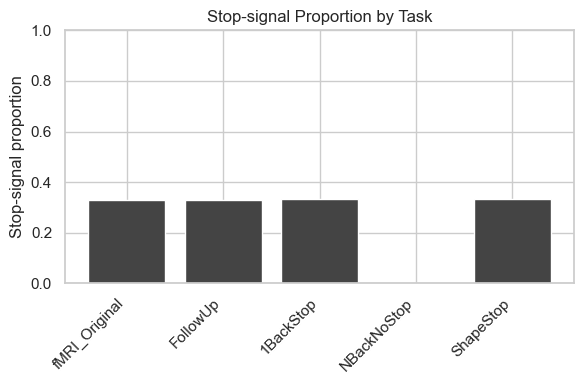

In [44]:
# ---------------------------
# Trial counts per condition x trial type
# ---------------------------

trial_counts_list = []

for task_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # ---- Stimulus label ----
    if task_name == "ShapeStop":
        df['stim_label'] = df[info['shape_col']].map(info['shape_map'])
    else:
        df['stim_label'] = df[info['stim_col']].map(info['stim_map'])

    # ---- Trial type ----
    if info['stop_go_col'] is not None:
        df['trial_type'] = df[info['stop_go_col']].map({info['stop_code']: 'Stop', info['go_code']: 'Go'})
        df['trial_label'] = df['trial_type'] + ' – ' + df['stim_label']
    else:
        df['trial_type'] = 'Go'
        df['trial_label'] = 'Go – ' + df['stim_label']

    # ---- Count trials per label ----
    counts = df.groupby('trial_label').size().reset_index(name='n_trials')
    counts['task'] = task_name
    trial_counts_list.append(counts)

# Combine all tasks
trial_counts = pd.concat(trial_counts_list, ignore_index=True)

# ---------------------------
# 1. Define trial types to include (for N-back)
# ---------------------------
trial_types_order = [
    "Go – Target", "Go – Non-target", "Go – Lure",
    "Stop – Target", "Stop – Non-target", "Stop – Lure"
]

# N-back tasks
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]

# ---------------------------
# 2. Pivot data for grouped bar plot
# ---------------------------
# Filter only N-back tasks
nback_counts = trial_counts[trial_counts["task"].isin(nback_tasks)]

# Pivot so that rows = trial_label, columns = task
pivot_df = nback_counts.pivot_table(
    index="trial_label",  # <-- corrected column name
    columns="task",
    values="n_trials",
    fill_value=0
)

# Reorder rows to desired trial type order
pivot_df = pivot_df.reindex(trial_types_order)

# ---------------------------
# 3. Plot grouped bar chart
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.2
x = np.arange(len(trial_types_order))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, task in enumerate(nback_tasks):
    ax.bar(x + i*bar_width, pivot_df[task], width=bar_width, label=task, color=colors[i])

ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(trial_types_order, rotation=45, ha="right")
ax.set_ylabel("Number of trials")
ax.set_title("Trial Counts Across N-back Task Variants")
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

# ---------------------------
# 4. Plot ShapeStop separately
# ---------------------------
shape_data = trial_counts[trial_counts["task"] == "ShapeStop"].copy()

plt.figure(figsize=(5,5))
plt.bar(shape_data["trial_label"], shape_data["n_trials"], color="#9467bd")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of trials")
plt.title("Trial Counts: No N-back Shape Discrimination Stop-Signal Task")
plt.tight_layout()
plt.show()








# ---------------------------
# 5. Stop signal proportion
# ---------------------------


stop_props = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Total trials
    total_trials = len(df)

    stop_col = info.get('stop_go_col')
    go_code = info.get('go_code')
    stop_code = info.get('stop_code')

    if stop_col is not None and go_code is not None and stop_code is not None:
        n_stop = (df[stop_col] == stop_code).sum()
        n_go = (df[stop_col] == go_code).sum()
        prop = n_stop / (n_stop + n_go)
    else:
        # If no stop/go column, assume all go trials
        n_stop = 0
        n_go = total_trials
        prop = 0

    stop_props.append({
        "Task": task,
        "n_go": n_go,
        "n_stop": n_stop,
        "stop_signal_proportion": prop
    })

stop_props_df = pd.DataFrame(stop_props)
print(stop_props_df)

plt.figure(figsize=(6,4))
plt.bar(stop_props_df["Task"], stop_props_df["stop_signal_proportion"], color="#444444")
plt.ylabel("Stop-signal proportion")
plt.title("Stop-signal Proportion by Task")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


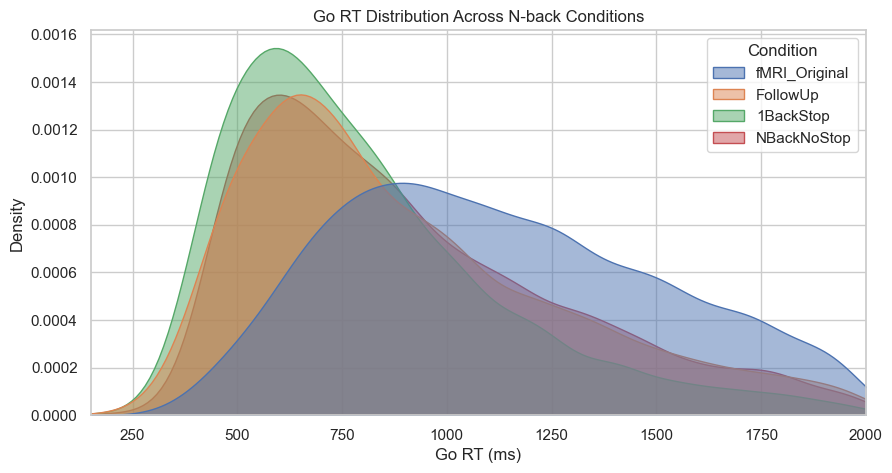

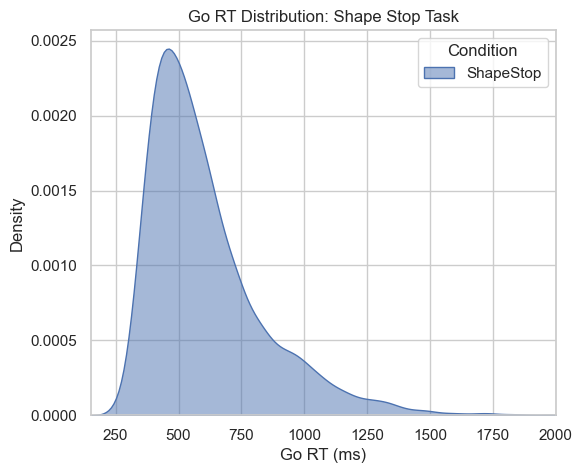

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Prepare data for Go RTs
# ---------------------------
rt_list = []

for task, info in files_info.items():
    df = pd.read_excel(info["file"])
    
    # Clean subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    # Only include tasks with a stop/go column for Go RT selection
    if info.get("stop_go_col") is not None:
        # Filter Go trials and realistic RTs
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df = df[df[info["stop_go_col"]] == info["go_code"]]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])
    else:
        # For tasks with no stop/go (ShapeStop), include all RTs within range
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])

rt_df = pd.concat(rt_list, ignore_index=True)

# ---------------------------
# 2. Split into N-back vs ShapeStop
# ---------------------------
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]
shape_task = ["ShapeStop"]

rt_nback = rt_df[rt_df["Condition"].isin(nback_tasks)]
rt_shape = rt_df[rt_df["Condition"].isin(shape_task)]

# ---------------------------
# 3. Plot Go RT distributions
# ---------------------------
sns.set(style="whitegrid")

# N-back panel
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=rt_nback, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution Across N-back Conditions")
plt.show()

# ShapeStop panel
plt.figure(figsize=(6,5))
sns.kdeplot(
    data=rt_shape, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution: Shape Stop Task")
plt.show()



/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_22856/4182431367.py:52: Fu

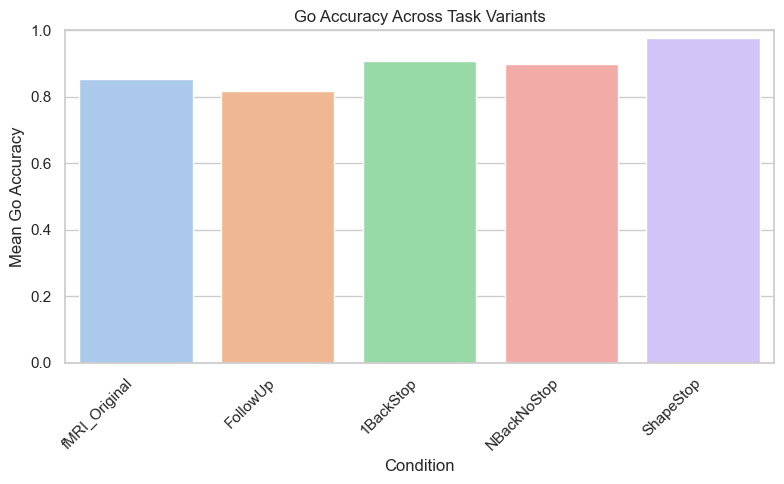

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acc_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace

    # Standardize subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)

    # Filter Go trials if stop/go column exists
    if info.get('stop_go_col') is not None:
        go_df = df[df[info['stop_go_col']] == info['go_code']].copy()
    else:
        go_df = df.copy()  # everything is Go

    # Handle Go accuracy
    go_acc_col = info.get('go_acc')
    if go_acc_col is not None and go_acc_col in df.columns:
        go_df['acc'] = go_df[go_acc_col]
    else:
        # If no go_acc, use adaptive_acc if available
        if 'adaptive_acc' in df.columns:
            go_df['acc'] = go_df['adaptive_acc']
        else:
            # If no accuracy data, set as NaN
            go_df['acc'] = pd.Series([None] * len(go_df))

    # Compute mean accuracy per subject
    mean_acc = go_df.groupby('subject')['acc'].mean().reset_index()
    mean_acc['Condition'] = task

    acc_list.append(mean_acc)

# Combine all tasks
acc_df = pd.concat(acc_list, ignore_index=True)

# Compute mean accuracy per condition, keeping NaN values if necessary
mean_acc_df = acc_df.groupby('Condition')['acc'].mean().reset_index()

# Optional: order conditions
condition_order = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop", "ShapeStop"]
mean_acc_df['Condition'] = pd.Categorical(mean_acc_df['Condition'], categories=condition_order, ordered=True)
mean_acc_df = mean_acc_df.sort_values('Condition')

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=mean_acc_df, x='Condition', y='acc', palette='pastel')
plt.ylim(0,1)
plt.ylabel('Mean Go Accuracy')
plt.title('Go Accuracy Across Task Variants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


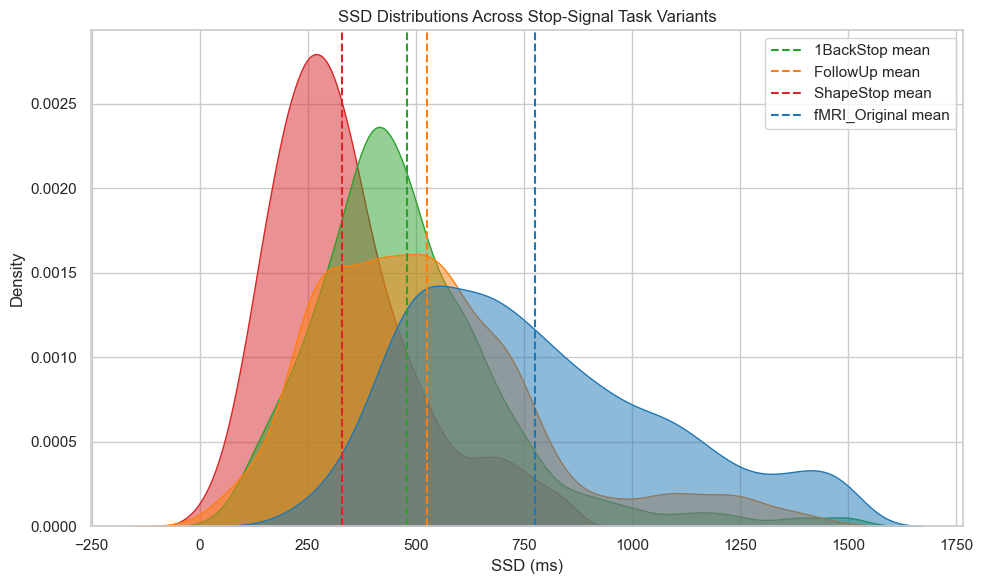

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Gather SSDs from all tasks
# ---------------------------
ssd_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove any weird spaces

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only include trials that have SSD (skip tasks without stop signals)
    if info.get('ssd_col') is not None:
        df = df[df[info['stop_go_col']] == info['stop_code']]  # only Stop trials
        df['Condition'] = task
        df['SSD'] = df[info['ssd_col']]
        ssd_list.append(df[['subject', 'Condition', 'SSD']])

# Combine all tasks
ssd_df = pd.concat(ssd_list, ignore_index=True)

# ---------------------------
# 2. Plot SSD distributions
# ---------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Define colors to match conditions
conditions = ssd_df['Condition'].unique()
palette = sns.color_palette("tab10", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

# KDE per task
sns.kdeplot(
    data=ssd_df,
    x='SSD',
    hue='Condition',
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette=color_map
)

# Overlay mean SSD as vertical lines with matching colors
mean_ssd = ssd_df.groupby('Condition')['SSD'].mean()
for cond, mean_val in mean_ssd.items():
    plt.axvline(mean_val, linestyle='--', color=color_map[cond], label=f'{cond} mean')

plt.xlabel("SSD (ms)")
plt.ylabel("Density")
plt.title("SSD Distributions Across Stop-Signal Task Variants")
plt.legend()
plt.tight_layout()
plt.show()



/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_22856/2538480958.py:36: Fu

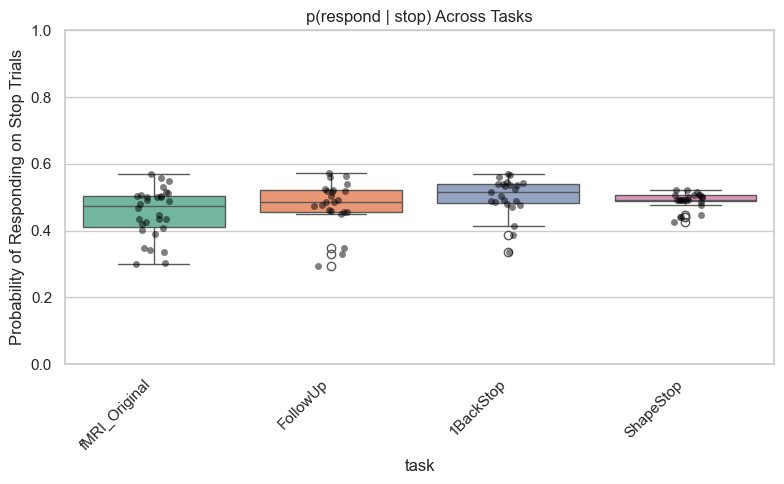

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# List to collect stop trial performance
stop_prob_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # clean column names

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only process tasks with stop trials
    if info.get('stop_go_col') is not None:
        # Identify stop trials
        stop_trials = df[df[info['stop_go_col']] == info['stop_code']].copy()
        
        # Probability of responding on stop trial: 1 = responded, 0 = successfully inhibited
        # If StopAcc column is 1 = successful stop, 0 = failed stop
        # Then responding = 1 - StopAcc
        stop_trials['responded'] = 1 - stop_trials[info['stop_acc_col']]

        # Compute mean per subject
        subj_mean = stop_trials.groupby('subject')['responded'].mean().reset_index()
        subj_mean['task'] = task
        stop_prob_list.append(subj_mean)

# Combine all tasks
stop_prob_df = pd.concat(stop_prob_list, ignore_index=True)

# ---------------------------
# Plot probability of responding given a stop signal
# ---------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=stop_prob_df, x='task', y='responded', palette="Set2")
sns.stripplot(data=stop_prob_df, x='task', y='responded', color='black', alpha=0.5, jitter=True)
plt.ylabel("Probability of Responding on Stop Trials")
plt.ylim(0,1)
plt.title("p(respond | stop) Across Tasks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_22856/3032222325.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', len(loads))


Data Preview (Subject, Load, N-Back Outcome, Acc):
   subject  Load n_back_outcome  acc
0      119   4.0            NaN  1.0
1      119   3.0   Stop Failure  1.0
2      119   2.0             Go  1.0
3      119   2.0             Go  1.0
4      119   1.0             Go  1.0


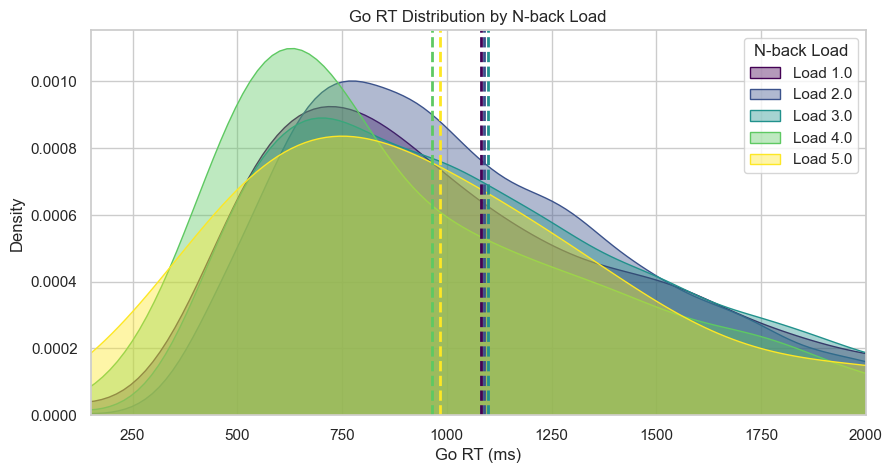

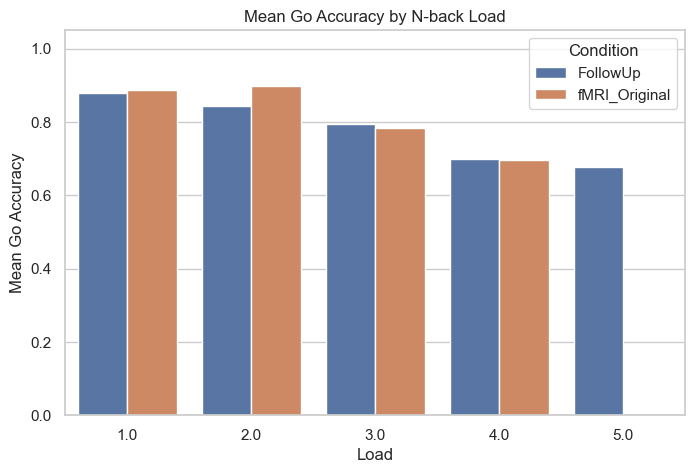

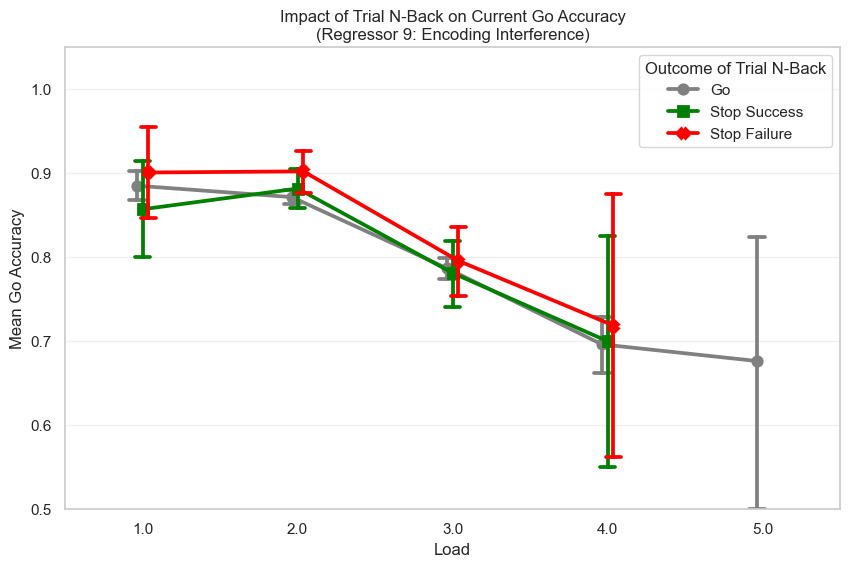

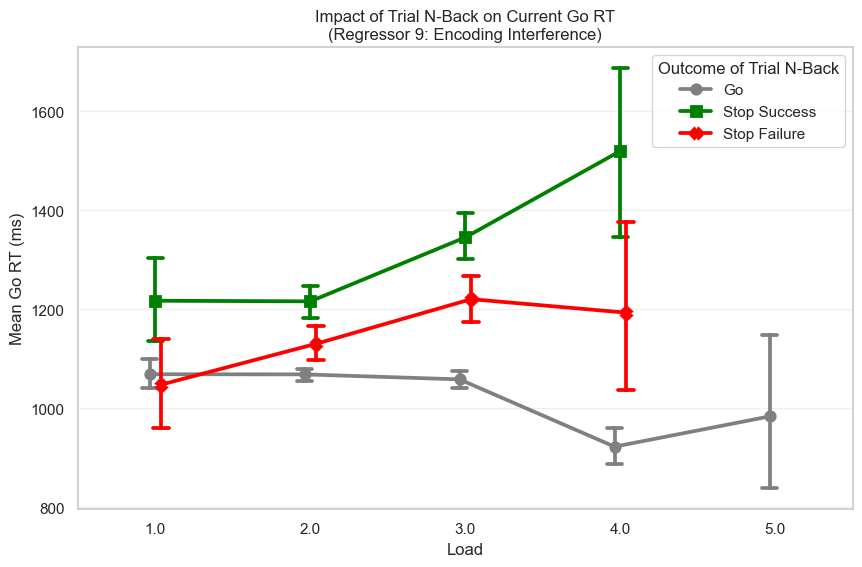

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

# ---------------------------
# 1. SETUP & DATA PREPARATION
# ---------------------------
load_tasks = ["fMRI_Original", "FollowUp"]
load_data_list = []

# Placeholder for files_info (Ensure this dictionary is defined in your script)
# files_info = { ... } 

for task in load_tasks:
    if task not in files_info:
        print(f"Skipping {task}: Not found in files_info")
        continue

    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # --- Standardize Columns ---
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    load_col = next((c for c in df.columns if c.lower() == 'load'), None)
    if load_col is None: raise ValueError(f"No 'Load' column in {task}")
    df['Load'] = df[load_col]

    trial_col = next((c for c in df.columns if c.lower() in ['trial', 'trialnum', 'trial_num', 'trial_index']), None)
    if trial_col is None: raise ValueError(f"No trial column in {task}")

    # --- CRITICAL: Sort strictly to establish the timeline ---
    df = df.sort_values(['subject', trial_col])

    # ---------------------------------------------------------
    # STEP A: Define outcomes for ALL trials (before filtering)
    # ---------------------------------------------------------
    # 1. Identify Stop vs Go
    if info.get('stop_go_col'):
        df['is_stop_trial'] = df[info['stop_go_col']] != info['go_code']
    else:
        df['is_stop_trial'] = False 

    # 2. Label the outcome of every trial
    df['outcome_label'] = 'Go' # Default
    
    if 'StopAcc' in df.columns:
        df.loc[(df['is_stop_trial']) & (df['StopAcc'] == 1), 'outcome_label'] = 'Stop Success'
        df.loc[(df['is_stop_trial']) & (df['StopAcc'] == 0), 'outcome_label'] = 'Stop Failure'
    elif 'NoStop1StopSuccess2StopFail3' in df.columns:
        df.loc[df['NoStop1StopSuccess2StopFail3'] == 2, 'outcome_label'] = 'Stop Success'
        df.loc[df['NoStop1StopSuccess2StopFail3'] == 3, 'outcome_label'] = 'Stop Failure'
    elif 'StopTrialType' in df.columns:
        df.loc[df['StopTrialType'] == 'StopSuccess', 'outcome_label'] = 'Stop Success'
        df.loc[df['StopTrialType'] == 'StopFail', 'outcome_label'] = 'Stop Failure'

    # ---------------------------------------------------------
    # STEP B: The "Regressor 9" Logic (Dynamic N-Back History)
    # ---------------------------------------------------------
    # We need to look back 'Load' number of trials.
    # Since 'Load' varies by row, we create shift columns for every possible load first.
    
    max_load = int(df['Load'].max())
    
    # Create columns: 'outcome_minus_1', 'outcome_minus_2', etc.
    for i in range(1, max_load + 1):
        df[f'outcome_minus_{i}'] = df.groupby('subject')['outcome_label'].shift(i)

    # Now select the correct history column based on the current row's Load
    # Logic: If Load is 2, grab value from 'outcome_minus_2'
    condition_list = [df['Load'] == i for i in range(1, max_load + 1)]
    choice_list = [df[f'outcome_minus_{i}'] for i in range(1, max_load + 1)]
    
    # np.select applies the logic row-by-row efficiently
    df['n_back_outcome'] = np.select(condition_list, choice_list, default='Unknown')

    # ---------------------------------------------------------
    # STEP C: Filter for Analysis (Keep only Go Trials)
    # ---------------------------------------------------------
    if info.get('stop_go_col'):
        df = df[df[info['stop_go_col']] == info['go_code']].copy()

    # Standardize Accuracy and RT
    acc_col = 'GoAcc' if 'GoAcc' in df.columns else 'go_acc'
    df['acc'] = df[acc_col] if acc_col in df.columns else 1 
    
    if info.get('ssd_col') in df.columns:
        df['SSD'] = df[info['ssd_col']]
    
    df['Condition'] = task
    
    # Filter out start-of-block trials where history is unknown
    df = df[df['n_back_outcome'] != 'Unknown']
    
    load_data_list.append(df)

# Combine datasets
load_df = pd.concat(load_data_list, ignore_index=True)

# Debug: Check if it worked
print("Data Preview (Subject, Load, N-Back Outcome, Acc):")
print(load_df[['subject', 'Load', 'n_back_outcome', 'acc']].head())


# ---------------------------
# 2. PLOTTING
# ---------------------------

# === PLOT 1: Original Go RT Distribution (KDE) ===
plt.figure(figsize=(10,5))

loads = sorted(load_df['Load'].unique())
cmap = cm.get_cmap('viridis', len(loads))
color_map = {load: cmap(i) for i, load in enumerate(loads)}

for load in loads:
    subset = load_df[load_df['Load'] == load]
    sns.kdeplot(
        data=subset, x='RT', fill=True, alpha=0.4,
        color=color_map[load], common_norm=False, label=f"Load {load}"
    )
    mean_rt = subset['RT'].mean()
    plt.axvline(mean_rt, linestyle='--', color=color_map[load], linewidth=2)

plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution by N-back Load")
plt.xlim(150, 2000)
plt.legend(title="N-back Load")
plt.show()

# === PLOT 2: Original Mean Go Accuracy by Load ===
acc_by_load = load_df.groupby(['Condition', 'Load'])['acc'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=acc_by_load, x='Load', y='acc', hue='Condition')
plt.ylabel("Mean Go Accuracy")
plt.ylim(0, 1.05)
plt.title("Mean Go Accuracy by N-back Load")
plt.legend(title="Condition")
plt.show()

# === PLOT 3: Regressor 9 Logic - Accuracy ===
# Question: Is Go Accuracy lower if the N-back target was a Stop Failure?
plt.figure(figsize=(10,6))
sns.pointplot(
    data=load_df,
    x='Load',
    y='acc',
    hue='n_back_outcome',
    hue_order=['Go', 'Stop Success', 'Stop Failure'],
    palette={'Go': 'gray', 'Stop Success': 'green', 'Stop Failure': 'red'},
    dodge=True,
    markers=['o', 's', 'X'],
    capsize=0.1
)
plt.ylabel("Mean Go Accuracy")
plt.title("Impact of Trial N-Back on Current Go Accuracy\n(Regressor 9: Encoding Interference)")
plt.ylim(0.5, 1.05)
plt.legend(title="Outcome of Trial N-Back")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# === PLOT 4: Regressor 9 Logic - RT ===
# Question: Is Go RT slower if the N-back target was a Stop Failure?
plt.figure(figsize=(10,6))
sns.pointplot(
    data=load_df,
    x='Load',
    y='RT',
    hue='n_back_outcome',
    hue_order=['Go', 'Stop Success', 'Stop Failure'],
    palette={'Go': 'gray', 'Stop Success': 'green', 'Stop Failure': 'red'},
    dodge=True,
    markers=['o', 's', 'X'],
    capsize=0.1
)
plt.ylabel("Mean Go RT (ms)")
plt.title("Impact of Trial N-Back on Current Go RT\n(Regressor 9: Encoding Interference)")
plt.legend(title="Outcome of Trial N-Back")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

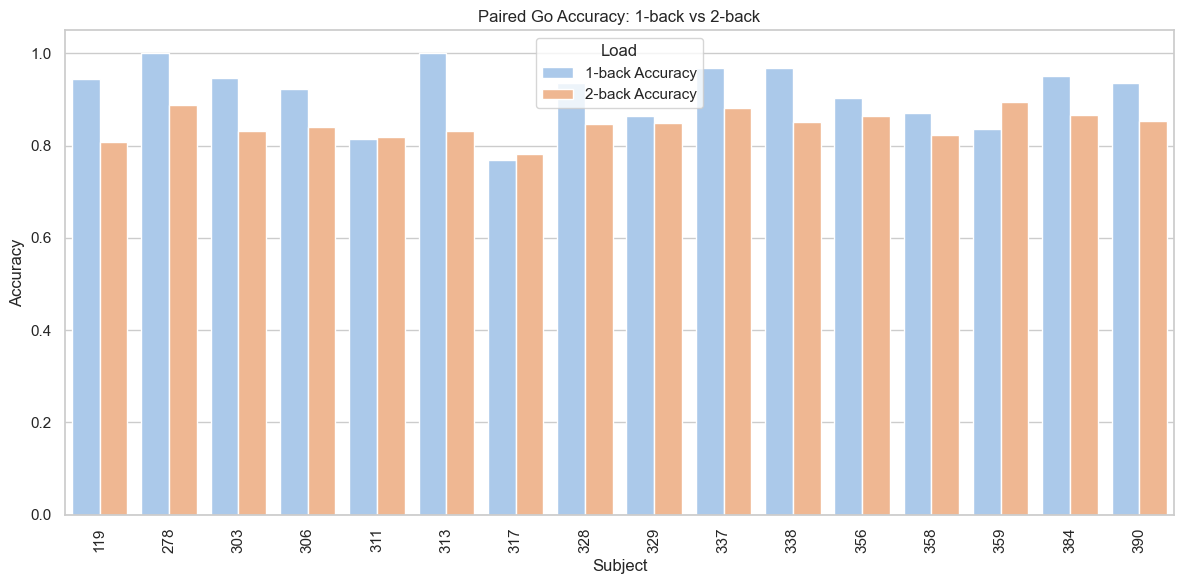

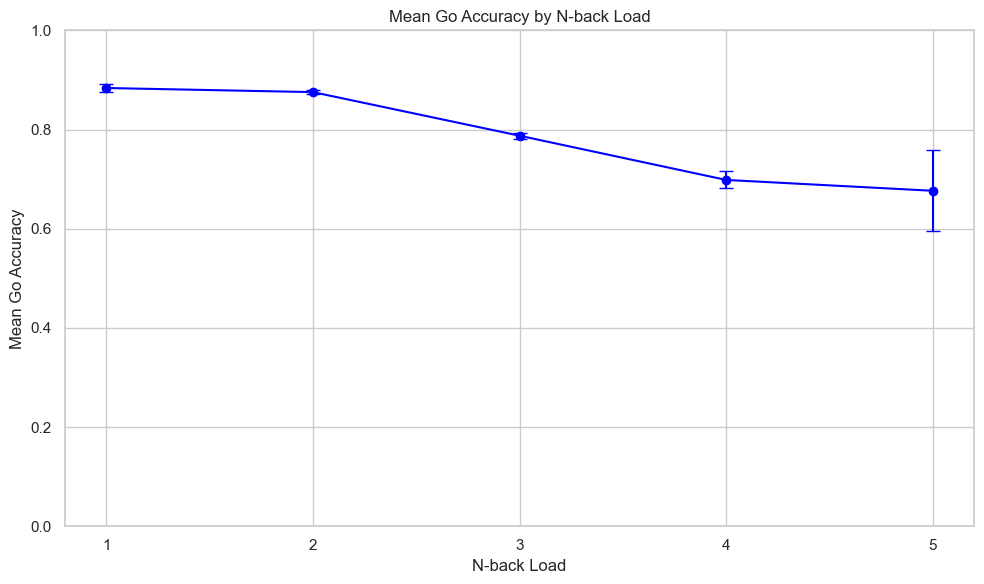

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 1-back and 2-back loads
one_back_df = load_df[load_df['Load'] == 1]
two_back_df = load_df[load_df['Load'] == 2]

# Identify subjects who have data for both 1-back and 2-back
subjects_1_back = set(one_back_df['subject'].unique())
subjects_2_back = set(two_back_df['subject'].unique())
common_subjects = list(subjects_1_back.intersection(subjects_2_back))

# Extract accuracy data for these common subjects
one_back_acc = one_back_df[one_back_df['subject'].isin(common_subjects)].groupby('subject')['acc'].mean()
two_back_acc = two_back_df[two_back_df['subject'].isin(common_subjects)].groupby('subject')['acc'].mean()

# Combine the data into a single DataFrame for plotting
accuracy_df = pd.DataFrame({
    'Subject': common_subjects,
    '1-back Accuracy': one_back_acc.loc[common_subjects].values,
    '2-back Accuracy': two_back_acc.loc[common_subjects].values
})

# Melt the DataFrame for a paired bar plot
melted_df = accuracy_df.melt(id_vars='Subject', value_vars=['1-back Accuracy', '2-back Accuracy'],
                             var_name='Load', value_name='Accuracy')

# Plot paired bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=melted_df, x='Subject', y='Accuracy', hue='Load', palette='pastel')

plt.xlabel('Subject')
plt.ylabel('Accuracy')
plt.title('Paired Go Accuracy: 1-back vs 2-back')
plt.xticks(rotation=90)
plt.legend(title='Load')
plt.tight_layout()
plt.show()


###Line pk

# Calculate mean accuracy for each load
mean_accuracy = load_df.groupby('Load')['acc'].mean().reset_index()

# Calculate standard error for each load
se_accuracy = load_df.groupby('Load')['acc'].sem().reset_index()

# Merge the mean and standard error data
summary_df = pd.merge(mean_accuracy, se_accuracy, on='Load', suffixes=('_mean', '_se'))

# Plot the line graph with error bars
plt.figure(figsize=(10, 6))
sns.lineplot(data=summary_df, x='Load', y='acc_mean', marker='o', color='blue')

# Add error bars
plt.errorbar(summary_df['Load'], summary_df['acc_mean'], yerr=summary_df['acc_se'], fmt='o', color='blue', capsize=5)

plt.xlabel('N-back Load')
plt.ylabel('Mean Go Accuracy')
plt.title('Mean Go Accuracy by N-back Load')
plt.xticks(summary_df['Load'])
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()
